# Time Series Anomaly Detection 🚨

In many real-world applications (like server monitoring, predictive maintenance, or fraud detection), we aren't just interested in predicting the future, but rather in identifying **when something has gone wrong**.

In this notebook, we'll demonstrate two approaches to Anomaly Detection in Time Series:
1. **Unsupervised Machine Learning:** Isolation Forest with rolling features.
2. **Deep Learning:** PyTorch Autoencoders (reconstruction loss).

First, let's load a standard dataset and artificially inject some synthetic "shocks" and "drops" (anomalies) so we can see how well our models detect them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

## 1. Data Preparation and Anomaly Injection

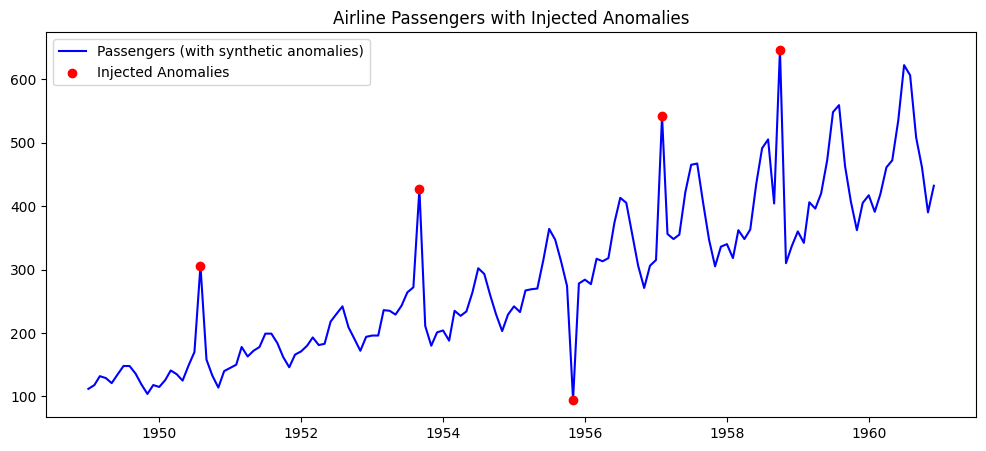

In [2]:
# Load the dataset
df = pd.read_csv('data/airline_passengers.csv')
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
df = df.rename(columns={'Thousands of Passengers': 'Passengers'})
df['Passengers'] = df['Passengers'].astype(float)

# Inject Synthetic Anomalies
np.random.seed(42)
anomalies_indices = np.random.choice(len(df), size=5, replace=False)

# Add random spikes or drops
df['True_Anomaly'] = 0
for idx in anomalies_indices:
    # 50% chance of a spike, 50% chance of a drop
    multiplier = np.random.choice([1.8, 0.4]) 
    df.iloc[idx, 0] = df.iloc[idx, 0] * multiplier
    df.iloc[idx, 1] = 1 # Mark as true anomaly

# Plot the data
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Passengers'], label='Passengers (with synthetic anomalies)', color='blue')

# Highlight true anomalies
anomalous_data = df[df['True_Anomaly'] == 1]
plt.scatter(anomalous_data.index, anomalous_data['Passengers'], color='red', label='Injected Anomalies', zorder=5)

plt.title('Airline Passengers with Injected Anomalies')
plt.legend()
plt.show()

## 2. Approach 1: Isolation Forest (Machine Learning)

Isolation Forest works by randomly partitioning the data. Anomalies (outliers) require fewer random partitions to be isolated compared to normal data points. 
For time series, it's often helpful to feed the model some context, like rolling statistics, instead of just the raw value at time $t$.

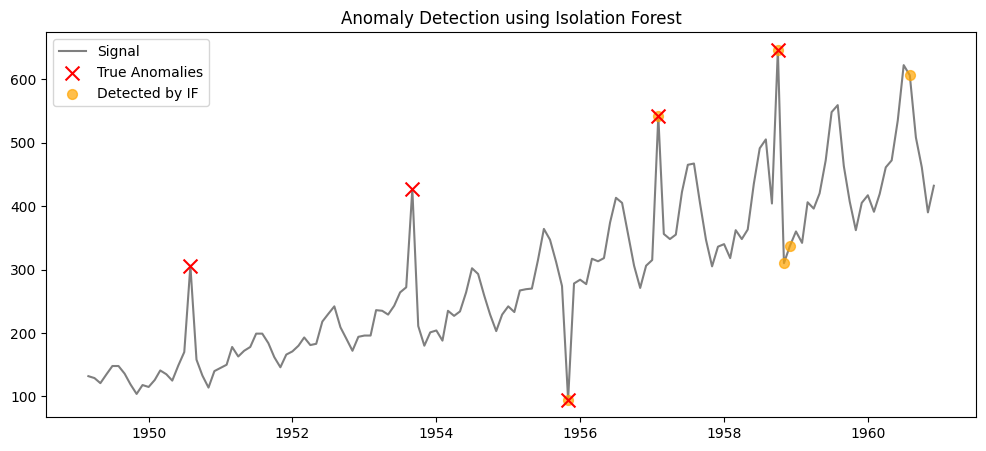

In [3]:
# Feature Engineering for Isolation Forest
df_if = df.copy()

# Add rolling window features to give temporal context
df_if['Rolling_Mean'] = df_if['Passengers'].rolling(window=3).mean()
df_if['Rolling_Std'] = df_if['Passengers'].rolling(window=3).std()

# Drop NaNs caused by rolling windows
df_if = df_if.dropna()

features = ['Passengers', 'Rolling_Mean', 'Rolling_Std']
X_if = df_if[features].values

# Standardize
scaler_if = StandardScaler()
X_if_scaled = scaler_if.fit_transform(X_if)

# Train Isolation Forest
# contamination defines the expected proportion of outliers (we injected 5 into ~144 points, so ~3.5%)
iso_forest = IsolationForest(contamination=0.04, random_state=42)
df_if['IF_Prediction'] = iso_forest.fit_predict(X_if_scaled)

# Isolation Forest outputs -1 for anomalies and 1 for normal points
df_if['IF_Anomaly'] = df_if['IF_Prediction'].apply(lambda x: 1 if x == -1 else 0)

# Evaluate visually
plt.figure(figsize=(12,5))
plt.plot(df_if.index, df_if['Passengers'], label='Signal', color='black', alpha=0.5)

# True vs Detected
plt.scatter(df_if[df_if['True_Anomaly'] == 1].index, df_if[df_if['True_Anomaly'] == 1]['Passengers'], 
            color='red', marker='x', s=100, label='True Anomalies', zorder=5)
plt.scatter(df_if[df_if['IF_Anomaly'] == 1].index, df_if[df_if['IF_Anomaly'] == 1]['Passengers'], 
            color='orange', marker='o', s=50, label='Detected by IF', zorder=4, alpha=0.7)

plt.title('Anomaly Detection using Isolation Forest')
plt.legend()
plt.show()

## 3. Approach 2: PyTorch Autoencoder (Deep Learning)

An Autoencoder is trained to reconstruct its input. We train it strictly on normal data (or data where anomalies are rare). When the autoencoder sees an anomalous sequence, it will fail to reconstruct it well. A high **Reconstruction Error** indicates an anomaly.

In [4]:
# Prepare sequence data
def create_sequences(data, seq_length):
    xs = []
    for i in range(len(data)-seq_length):
        x = data[i:(i+seq_length)]
        xs.append(x)
    return np.array(xs)

seq_length = 6 # Look at a 6-month window
scaler_ae = StandardScaler()
scaled_passengers = scaler_ae.fit_transform(df[['Passengers']])

X_ae = create_sequences(scaled_passengers, seq_length)
X_ae = torch.tensor(X_ae, dtype=torch.float32)

print(f"Sequence tensor shape: {X_ae.shape}")

Sequence tensor shape: torch.Size([138, 6, 1])


In [5]:
class TimeSeriesAutoencoder(nn.Module):
    def __init__(self, seq_len):
        super(TimeSeriesAutoencoder, self).__init__()
        
        # Encoder: Compresses the sequence to a smaller bottleneck
        self.encoder = nn.Sequential(
            nn.Linear(seq_len, 3),
            nn.ReLU(),
            nn.Linear(3, 1) # Bottleneck
        )
        
        # Decoder: Tries to reconstruct the original sequence from the bottleneck
        self.decoder = nn.Sequential(
            nn.Linear(1, 3),
            nn.ReLU(),
            nn.Linear(3, seq_len)
        )

    def forward(self, x):
        # x shape: (batch_size, seq_len, 1) -> flatten to (batch_size, seq_len)
        x = x.squeeze(2)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        # Reshape back to (batch_size, seq_len, 1)
        return decoded.unsqueeze(2)

model = TimeSeriesAutoencoder(seq_len=seq_length)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

print(model)

TimeSeriesAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=6, out_features=3, bias=True)
    (1): ReLU()
    (2): Linear(in_features=3, out_features=1, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=1, out_features=3, bias=True)
    (1): ReLU()
    (2): Linear(in_features=3, out_features=6, bias=True)
  )
)


In [6]:
# Train the Autoencoder
EPOCHS = 200

# We train on all data. In a strict setup, you'd filter out known anomalies first.
# But Autoencoders are somewhat robust if anomalies are sparse.
model.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    reconstructed = model(X_ae)
    loss = criterion(reconstructed, X_ae)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {loss.item():.4f}')

Epoch [50/200], Loss: 0.1948
Epoch [100/200], Loss: 0.1629
Epoch [150/200], Loss: 0.1586
Epoch [200/200], Loss: 0.1574


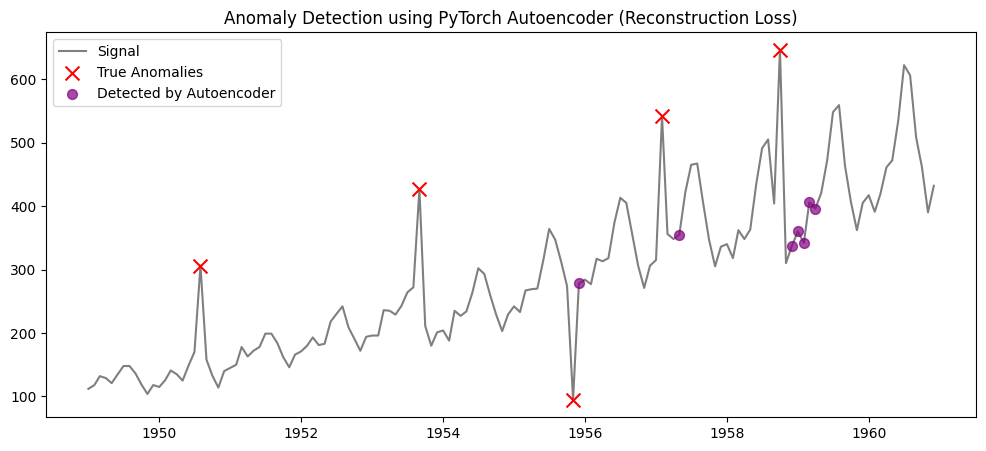

In [7]:
# Calculate Reconstruction Loss for each sequence
model.eval()
with torch.no_grad():
    reconstructed = model(X_ae)
    # Calculate MSE for each sequence individually
    # Shape: (num_sequences, seq_length, 1)
    loss_per_sequence = torch.mean(torch.square(reconstructed - X_ae), dim=[1,2])

losses = loss_per_sequence.numpy()

# Determine Threshold (e.g., 95th percentile of losses)
threshold = np.percentile(losses, 95)

# Map anomalies back to original DataFrame
# Since a sequence covers [t, t+seq_length], we attribute the loss to the end of the window (t+seq_length)
df['AE_Anomaly'] = 0
for i, loss in enumerate(losses):
    if loss > threshold:
        # i maps to index i + seq_length in original dataframe
        df.iloc[i + seq_length, df.columns.get_loc('AE_Anomaly')] = 1

# Plot
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Passengers'], label='Signal', color='black', alpha=0.5)

# True vs Detected
plt.scatter(df[df['True_Anomaly'] == 1].index, df[df['True_Anomaly'] == 1]['Passengers'], 
            color='red', marker='x', s=100, label='True Anomalies', zorder=5)
plt.scatter(df[df['AE_Anomaly'] == 1].index, df[df['AE_Anomaly'] == 1]['Passengers'], 
            color='purple', marker='o', s=50, label='Detected by Autoencoder', zorder=4, alpha=0.7)

plt.axhline(scaler_ae.inverse_transform([[threshold]])[0][0], color='r', linestyle='--', alpha=0) # dummy line

plt.title('Anomaly Detection using PyTorch Autoencoder (Reconstruction Loss)')
plt.legend()
plt.show()

### Conclusion
Both Machine Learning (Isolation Forest) and Deep Learning (Autoencoders) provide robust mechanisms for detecting anomalies without needing massive amounts of explicitly labeled bad data!